In [1]:
# 実行環境・ライフサイクル・安全な記録
from pathlib import Path
from datetime import datetime, timezone
import os, json, hashlib, inspect, io, contextlib
import nbformat
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = '/home/nahisaho/GitHub/jupytermind/benchmark/projects'
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity, notebook_audit
RUN_ID = 'v020-exp-45'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-45-product-reviews')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
LANGUAGE = language_router.detect_language('評価点とレビュー本文の関連を日本語で分析してください')
def append_cell(source, kind='markdown'):
    lifecycle.mark_write_start(RUN_ID)
    try:
        cell = nbformat.v4.new_markdown_cell(source) if kind == 'markdown' else nbformat.v4.new_code_cell(source)
        pm.enqueue_write(handle, lambda nb: nb.cells.append(cell))
    finally:
        lifecycle.mark_write_end(RUN_ID)
print('run_id:', RUN_ID, 'language:', LANGUAGE)
print('notebook:', handle.notebook_path)
for obj in [data_definition.build_manifest, analysis_assumptions.Assumption, analysis_assumptions.AnalysisAssumptionManifest, analysis_assumptions.check_manifest, data_quality.detect_anomalies, sensitivity.SensitivityPlan, sensitivity.run_sensitivity, notebook_audit.audit_notebook]:
    print(obj.__name__, inspect.signature(obj))
print('lifecycle public:', [n for n in dir(lifecycle) if not n.startswith('_')])

run_id: v020-exp-45 language: ja
notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-45-product-reviews/notebooks/kaggle-v020-kaggle-exp-45-product-reviews.ipynb
build_manifest (source: 'dict', dataset_scope: 'dict', variables: 'dict[str, dict[str, FieldValue]]', transformations: 'tuple' = ()) -> 'DataDefinitionManifest'
Assumption (id: 'str', statement: 'str', status: 'str', evidence_cell: 'int | None' = None, impact_if_false: 'str | None' = None, conclusion_critical: 'bool' = False) -> None
AnalysisAssumptionManifest (analysis_scope: 'dict', assumptions: 'tuple[Assumption, ...]' = <factory>, causal_scope: 'str' = 'descriptive', sampling: 'dict | None' = None) -> None
check_manifest (manifest: 'AnalysisAssumptionManifest') -> 'tuple[AssumptionFinding, ...]'
detect_anomalies (df: 'pd.DataFrame', schema: 'dict') -> 'tuple[AnomalyRecord, ...]'
SensitivityPlan (parameter_grid: 'dict[str, list[Any]]', max_runs: 'int' = 100) -> None
run_sensitivity (plan: '

# EC商品レビュー：評価点と本文表現

run_id: `v020-exp-45`。Kaggle公開データをSDKで検索し、実データ取得後に言語・欠損・重複・クラス不均衡を確認する。単語のレビュー内出現率を主分析とし、辞書の適合性が未確認の感情スコアを評価の代替としない。因果推論ではなく記述的・関連的分析。認証情報・例外本文・SDKログは出力しない。

In [2]:
# Kaggle SDK検索（認証情報は表示しない）
search_log = []
api = None
kaggle_error = None
lifecycle.mark_execution_start(RUN_ID)
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        try:
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            datasets = api.dataset_list(search='ecommerce product reviews')
        except (Exception, SystemExit) as exc:
            kaggle_error = {'stage': 'authenticate_or_dataset_list', 'exception_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)}
    if kaggle_error:
        search_log.append(kaggle_error)
        print('Kaggle取得失敗（安全化）:', json.dumps(kaggle_error, ensure_ascii=False))
    else:
        search_results = [{'ref': d.ref, 'title': d.title, 'bytes': getattr(d, 'total_bytes', None)} for d in datasets]
        print(json.dumps(search_results, ensure_ascii=False, indent=2))
finally:
    lifecycle.mark_execution_end(RUN_ID)


[
  {
    "ref": "olistbr/brazilian-ecommerce",
    "title": "Brazilian E-Commerce Public Dataset by Olist",
    "bytes": 44717580
  },
  {
    "ref": "devsubhash/flipkart-mobiles-dataset",
    "title": "Flipkart Mobiles Dataset",
    "bytes": 55674
  },
  {
    "ref": "imrulhasanrobi/e-commerce-big-dataset-from-multi-category",
    "title": "E-commerce big Dataset from Multi category (60k+)",
    "bytes": 64744
  },
  {
    "ref": "promptcloud/walmart-product-data-2019",
    "title": "Walmart Product Data 2019",
    "bytes": 14308028
  },
  {
    "ref": "jithinanievarghese/flipkart-smartphones-dataset",
    "title": "Flipkart Smartphones Dataset",
    "bytes": 76982
  },
  {
    "ref": "anvitkumar/shopping-dataset",
    "title": "Ecommerce Dataset (Products & Sizes Included)",
    "bytes": 1274856
  },
  {
    "ref": "nicapotato/womens-ecommerce-clothing-reviews",
    "title": "Women's E-Commerce Clothing Reviews",
    "bytes": 2924120
  },
  {
    "ref": "kartikeybartwal/ecomerce-pro

## データ選定と取得
検索結果で確認した `nicapotato/womens-ecommerce-clothing-reviews` を選ぶ。EC衣料品のレビュー本文と1～5段階評価を含む候補で、サイズ・着心地等の表現を分析できる規模。女性向け衣料品に限定され、EC全体の代表標本ではない。API取得成功時は外部CSVへフォールバックしない。

In [3]:
# 公開ファイル一覧・ダウンロード・出所記録
import pandas as pd
import numpy as np
import zipfile
from urllib.parse import quote
from zoneinfo import ZoneInfo
SLUG = 'nicapotato/womens-ecommerce-clothing-reviews'
FILENAME = 'Womens Clothing E-Commerce Reviews.csv'
provenance = {'owner_dataset': SLUG, 'requested_filename': FILENAME, 'retrieved_at_utc': None, 'sha256': None, 'status': 'pending'}
if lifecycle.is_cancel_requested(RUN_ID):
    raise RuntimeError('キャンセル要求を検知')
lifecycle.mark_execution_start(RUN_ID)
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        try:
            if kaggle_error:
                raise RuntimeError('検索失敗のためダウンロード不可')
            listing = api.dataset_list_files(SLUG)
            available_files = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in listing.files]
            if FILENAME not in [f['name'] for f in available_files]:
                raise FileNotFoundError('対応CSVが公開ファイル一覧にない')
            api.dataset_download_file(SLUG, FILENAME, path=str(data_dir), force=True, quiet=True)
            api.dataset_metadata(SLUG, path=str(data_dir))
            source_metadata = json.loads((Path(data_dir) / 'dataset-metadata.json').read_text(encoding='utf-8'))['info']
        except (Exception, SystemExit) as exc:
            download_error = {'stage': 'list_files_or_download', 'exception_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)}
        else:
            download_error = None
    if download_error:
        provenance['status'] = 'failed'
        print('取得失敗（安全化）:', download_error)
        paper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        print('指定white-paper存在:', paper_path.exists())
        if paper_path.exists():
            paper = paper_path.read_text(encoding='utf-8')
            matching_lines = [line for line in paper.splitlines() if SLUG in line or FILENAME in line or 'exp-45' in line]
            print('同一データ確認候補:', matching_lines)
        lifecycle.mark_failed(RUN_ID)
    else:
        csv_path = Path(data_dir) / FILENAME
        if not csv_path.exists():
            archive_path = Path(data_dir) / (quote(FILENAME) + '.zip')
            with zipfile.ZipFile(archive_path) as z:
                if FILENAME not in z.namelist():
                    raise FileNotFoundError('ZIPに指定CSVがない')
                csv_path.write_bytes(z.read(FILENAME))
        provenance.update({'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'retrieved_date_jst': datetime.now(ZoneInfo('Asia/Tokyo')).date().isoformat(), 'filename': csv_path.name, 'bytes': csv_path.stat().st_size, 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'status': 'success', 'url': 'https://www.kaggle.com/datasets/' + SLUG})
        print('公開ファイル:', available_files)
        print('provenance:', json.dumps(provenance, ensure_ascii=False, indent=2))
        print('dataset title:', source_metadata.get('title'))
        print('public metadata keys:', sorted(source_metadata.keys()))
        print('公開データ定義抜粋:', source_metadata.get('description', '')[:4800])
        from ai_data_scientist import ingestion
        ingested = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(csv_path)), row_limit=100000)
        df = ingested.dataframe
        print('ingestion:', {'rows': ingested.row_count, 'truncated': ingested.truncated})
        print('shape:', df.shape, 'columns:', df.columns.tolist())
        print('dtypes:', df.dtypes.astype(str).to_dict())
finally:
    lifecycle.mark_execution_end(RUN_ID)


公開ファイル: [{'name': 'Womens Clothing E-Commerce Reviews.csv', 'bytes': 8483448}]
provenance: {
  "owner_dataset": "nicapotato/womens-ecommerce-clothing-reviews",
  "requested_filename": "Womens Clothing E-Commerce Reviews.csv",
  "retrieved_at_utc": "2026-10-01T23:16:07.027037+00:00",
  "sha256": "bd93cc515747ad1f87b8bc863c9e40da758509e6db6506a96d06976e61e36ee0",
  "status": "success",
  "retrieved_date_jst": "2026-10-02",
  "filename": "Womens Clothing E-Commerce Reviews.csv",
  "bytes": 8483448,
  "url": "https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews"
}
dataset title: Women's E-Commerce Clothing Reviews
public metadata keys: ['datasetId', 'datasetSlug', 'description', 'expectedUpdateFrequency', 'keywords', 'licenses', 'ownerUser', 'subtitle', 'title', 'totalDownloads', 'totalViews', 'totalVotes', 'usabilityRating']
公開データ定義抜粋: ### Context

Welcome. This is a Women’s Clothing E-Commerce dataset revolving around the reviews written by customers. Its nine sup

## 取得時の障害記録
初回はKaggle SDKに存在しない `dataset_view` を呼んだため AttributeError。ダウンロード自体は成功し、SDKが空白を `%20` に変換したZIP名で保存していた。`dataset_metadata` とURLエンコード済みファイル名へ修正し同一データで再試行。指定white-paperは存在したがslug・ファイル名の一致行なし。外部CSVへのフォールバックは未使用。これは取得コードとKaggle SDKのAPI差異であり、Jupytermind不具合ではない。

## データ定義manifest・分析前提manifestと品質確認
Ratingは公開データ辞書の1=最低、5=最高の順序尺度。行はレビューであり、投稿者ID・購入者母集団・時期は不明。本文が欠ける行を補完せず、本文分析の対象から除く。全文頻度ではなくレビュー単位の出現率を使い、高低評価群の件数差と同一レビュー内の反復語の影響を抑える。

In [4]:
# 定義・前提・品質・言語の再現可能な確認
from dataclasses import asdict
from ai_data_scientist import eda, cleaning, ingestion, visualization, insight_engine
from sklearn.feature_extraction.text import CountVectorizer
import re
lifecycle.mark_execution_start(RUN_ID)
try:
    F = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'url': F(provenance['url'], 'verified', 'SDK検索・ファイル一覧'), 'sha256': F(provenance['sha256'], 'verified', '取得CSVバイト列')},
        dataset_scope={'unit_of_observation': F('顧客レビュー1件', 'verified', 'Kaggle公開データ辞書'), 'population': F('匿名の女性向け衣料品ECレビュー', 'verified', 'Kaggle公開説明'), 'time_range': F(None, 'unknown'), 'reviewer_id': F(None, 'unknown'), 'language': F('主に英語と推定。自動言語判定器は未使用', 'inferred', '文字種・機能語確認')},
        variables={
            'Rating': {'definition': F('1=最低、5=最高の順序尺度', 'verified', 'Kaggle公開データ辞書'), 'unit': F('1～5段階', 'verified', 'Kaggle公開データ辞書')},
            'Review Text': {'definition': F('レビュー本文', 'verified', 'Kaggle公開データ辞書')},
            'Clothing ID': {'definition': F('衣料品の識別子（投稿者IDではない）', 'verified', 'Kaggle公開データ辞書')},
            'Unnamed: 0': {'definition': F('CSV出力行番号と推定', 'inferred', '連番・列名')}
        }, transformations=('本文欠損除外', '小文字化・空白正規化', '商品ID・評価・正規化本文の一致で重複除外', '語の出現を二値化'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str))
    print('未解決の定義:', definition_manifest.unresolved_fields())
    print('推定の定義:', {'language': '主に英語と推定、言語proxyは確定判定ではない', 'Unnamed: 0': '出力行番号と推定'})
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'question': '評価点と本文表現の関連', 'dataset': SLUG},
        assumptions=(
            analysis_assumptions.Assumption('A1', 'レビューを購入者全体の無作為標本とみなさない', 'assumed', impact_if_false='母集団一般化不可'),
            analysis_assumptions.Assumption('A2', '同一商品・評価・正規化本文を重複候補として除く', 'assumed', impact_if_false='別人の同文レビューを除く可能性', conclusion_critical=True),
            analysis_assumptions.Assumption('A3', 'ラテン文字と英語機能語を含む本文に英語tokenizerを使う', 'assumed', impact_if_false='非英語・短文の分類誤り', conclusion_critical=True),
            analysis_assumptions.Assumption('A4', '本文欠損除外後の結果は本文あり投稿に限定する', 'verified', impact_if_false='本文なし投稿の表現は識別不能')
        ), causal_scope='associational', sampling={'method': '全件、品質基準で対象制限', 'n': len(df), 'seed': 45})
    print('分析前提manifest:', json.dumps(asdict(assumption_manifest), ensure_ascii=False))
    print('前提検査finding:', [asdict(x) for x in analysis_assumptions.check_manifest(assumption_manifest)])
    quality_schema = {'Rating': {'allowed': [1,2,3,4,5], 'min': 1, 'max': 5, 'not_null': True}, 'Clothing ID': {'not_null': True, 'min': 0}, 'Age': {'min': 1, 'max': 120}, 'Recommended IND': {'allowed': [0,1]}, 'Positive Feedback Count': {'min': 0}, 'Unnamed: 0': {'unique': True, 'not_null': True}}
    semantic_anomalies = data_quality.detect_anomalies(df, quality_schema)
    print('意味的異常:', [asdict(x) for x in semantic_anomalies])
    missing = pd.DataFrame({'欠損数': df.isna().sum(), '欠損率': df.isna().mean()})
    print('欠損:', missing.to_string())
    text = df['Review Text'].fillna('').astype(str)
    normalized = text.str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
    work = df.assign(normalized=normalized)
    print('空本文数:', int(normalized.eq('').sum()))
    print('完全行重複:', int(df.duplicated().sum()), '行番号除外重複:', int(df.drop(columns='Unnamed: 0').duplicated().sum()))
    body = work.loc[normalized.ne('') & work['Rating'].isin([1,2,3,4,5])].copy()
    letters = body['normalized'].str.findall(r'[A-Za-z]').str.len()
    all_letters = body['normalized'].map(lambda s: sum(c.isalpha() for c in s))
    body['latin_ratio'] = letters / all_letters.replace(0, np.nan)
    body['english_signal'] = body['normalized'].str.contains(r'\b(?:the|and|is|this|it|was|to|for|with|but)\b', regex=True)
    body['language_proxy'] = body['latin_ratio'].ge(.9) & body['english_signal']
    print('言語proxy集計:', body.groupby('language_proxy').agg(n=('Rating','size'), mean_rating=('Rating','mean')).to_string())
    print('Latin比率分位:', body['latin_ratio'].quantile([0,.01,.5,1]).to_dict())
    print('非proxy例（最大80文字・上位8件）:', body.loc[~body['language_proxy'], 'normalized'].head(8).str[:80].tolist())
    dup_subset = ['Clothing ID','Rating','normalized']
    print('商品+評価+正規化本文重複候補:', int(body.duplicated(dup_subset).sum()), '本文のみ重複候補:', int(body.duplicated('normalized').sum()))
    base = body.loc[body['language_proxy']].copy()
    cleaning_report = cleaning.clean_dataset(base, operation='drop_duplicates', columns=dup_subset)
    print('cleaning指定キーの残存重複:', int(cleaning_report.dataframe.duplicated(dup_subset).sum()))
    analyzed = base.drop_duplicates(subset=dup_subset).copy()
    assert not analyzed.duplicated(dup_subset).any(), '指定キー重複が残存'
    print('pandas指定キー除去impact:', {'rows_before':len(base),'rows_after':len(analyzed),'rows_removed':len(base)-len(analyzed)})
    print('重複除去impact:', {k: getattr(cleaning_report, k) for k in ['rows_before','rows_after','rows_removed','columns_affected']})
    analyzed['group'] = np.select([analyzed['Rating'].le(2), analyzed['Rating'].eq(3)], ['低評価1–2', '中評価3'], default='高評価4–5')
    counts = pd.DataFrame({'全件': df['Rating'].value_counts(), '本文あり': body['Rating'].value_counts(), '分析対象': analyzed['Rating'].value_counts()}).sort_index()
    counts['本文欠損率'] = 1-counts['本文あり']/counts['全件']
    counts['分析対象構成比'] = counts['分析対象']/len(analyzed)
    print('評価別件数:', counts.to_string())
    print('群別件数:', analyzed['group'].value_counts().to_dict(), '分析対象数:', len(analyzed))
    print('EDA型:', type(eda.explore(df)).__name__)
    for obj in [ingestion.ingest, visualization.render_chart, visualization.build_image_output, insight_engine.record_insight, insight_engine.extract_cited_value]:
        print(obj.__name__, inspect.signature(obj))
finally:
    lifecycle.mark_execution_end(RUN_ID)

{'行数':len(df), '本文欠損数':int(df['Review Text'].isna().sum()), '分析対象数':len(analyzed), '意味的異常数':len(semantic_anomalies)}


データ定義manifest: {"source": {"url": {"value": "https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews", "status": "verified", "source": "SDK検索・ファイル一覧"}, "sha256": {"value": "bd93cc515747ad1f87b8bc863c9e40da758509e6db6506a96d06976e61e36ee0", "status": "verified", "source": "取得CSVバイト列"}}, "dataset_scope": {"unit_of_observation": {"value": "顧客レビュー1件", "status": "verified", "source": "Kaggle公開データ辞書"}, "population": {"value": "匿名の女性向け衣料品ECレビュー", "status": "verified", "source": "Kaggle公開説明"}, "time_range": {"value": null, "status": "unknown", "source": null}, "reviewer_id": {"value": null, "status": "unknown", "source": null}, "language": {"value": "主に英語と推定。自動言語判定器は未使用", "status": "inferred", "source": "文字種・機能語確認"}}, "variables": {"Rating": {"definition": {"value": "1=最低、5=最高の順序尺度", "status": "verified", "source": "Kaggle公開データ辞書"}, "unit": {"value": "1～5段階", "status": "verified", "source": "Kaggle公開データ辞書"}}, "Review Text": {"definition": {"value": "レビュー本文", "status": "ver

{'行数': 23486, '本文欠損数': 845, '分析対象数': 22522, '意味的異常数': 0}

## 初回分析：単語・連続2語のレビュー内出現率
言語proxyは言語判定ではなく分析上の保守的な制限である。除外例にも英語の短文があるため、除外を戻す感度分析が必要。最低50レビューに現れる表現を探索し、1–2点と4–5点を比較する。3点は除外せず評価別プロファイルで表示。語の二値化で長文の反復を抑えるが、長文ほど語を含みやすい問題は残る。感情辞書は衣料品・否定・皮肉への妥当性が未検証のため採用しない。

In [5]:
# 評価点と表現の関連（因果・予測精度ではない）
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
lifecycle.mark_execution_start(RUN_ID)
try:
    def tokenize_text(series):
        return series.str.replace(r"n['’]t\b", ' not', regex=True).str.findall(r'\b[a-z]+\b').str.join(' ')
    vectorizer = CountVectorizer(binary=True, ngram_range=(1,2), min_df=50, max_df=.8, token_pattern=r'(?u)\b[a-z]+\b')
    X = vectorizer.fit_transform(tokenize_text(analyzed['normalized']))
    terms = vectorizer.get_feature_names_out()
    stop = set(ENGLISH_STOP_WORDS) - {'not','no','never','nor','too'}
    eligible = np.array([any(w not in stop for w in term.split()) for term in terms])
    low_mask = analyzed['Rating'].le(2).to_numpy()
    high_mask = analyzed['Rating'].ge(4).to_numpy()
    low_n, high_n = int(low_mask.sum()), int(high_mask.sum())
    low_count = np.asarray(X[low_mask].sum(axis=0)).ravel()
    high_count = np.asarray(X[high_mask].sum(axis=0)).ravel()
    low_p, high_p = low_count/low_n, high_count/high_n
    term_table = pd.DataFrame({'表現':terms, '低群件数':low_count, '高群件数':high_count, '低群出現率':low_p, '高群出現率':high_p, '高低差pp':100*(high_p-low_p), 'log_OR高対低':np.log((high_count+.5)/(high_n-high_count+.5))-np.log((low_count+.5)/(low_n-low_count+.5))})
    term_table = term_table.loc[eligible].copy()
    print('特徴数:', X.shape[1], '低群n:', low_n, '高群n:', high_n)
    print('高評価側表現（差pp上位）:', term_table.nlargest(12,'高低差pp').to_string(index=False))
    print('低評価側表現（差pp下位）:', term_table.nsmallest(12,'高低差pp').to_string(index=False))
    anchors = ['love','perfect','comfortable','disappointed','cheap','return','not flattering','too small','too big']
    term_index = {t:i for i,t in enumerate(terms)}
    profiles = []
    for term in anchors:
        if term not in term_index:
            print('min_df未達/語彙外:', term)
            continue
        hit = X[:,term_index[term]].toarray().ravel().astype(bool)
        for rating in range(1,6):
            mask = analyzed['Rating'].eq(rating).to_numpy()
            profiles.append({'表現':term, '評価点':rating, '群内n':int(mask.sum()), '出現件数':int(hit[mask].sum()), '出現率':float(hit[mask].mean())})
    profile_df = pd.DataFrame(profiles)
    print('評価別出現率:', profile_df.pivot(index='表現', columns='評価点', values='出現率').to_string())
    analyzed['word_count'] = analyzed['normalized'].str.findall(r'\b[a-z]+\b').str.len()
    print('評価別語数:', analyzed.groupby('Rating')['word_count'].agg(['count','median','mean']).to_string())
    print('本文欠損845件; 主分析22522件; 高低群比=', high_n/low_n)
    print('EVIDENCE_LOVE_DELTA_PP=' + str(float(term_table.loc[term_table['表現'].eq('love'),'高低差pp'].iloc[0])))
    print('EVIDENCE_DISAPPOINTED_DELTA_PP=' + str(float(term_table.loc[term_table['表現'].eq('disappointed'),'高低差pp'].iloc[0])))
finally:
    lifecycle.mark_execution_end(RUN_ID)

'EVIDENCE_LOVE_DELTA_PP=' + str(float(term_table.loc[term_table['表現'].eq('love'),'高低差pp'].iloc[0])) + '; EVIDENCE_DISAPPOINTED_DELTA_PP=' + str(float(term_table.loc[term_table['表現'].eq('disappointed'),'高低差pp'].iloc[0]))


特徴数: 5100 低群n: 2360 高群n: 17350
高評価側表現（差pp上位）:          表現  低群件数  高群件数    低群出現率    高群出現率     高低差pp  log_OR高対低
       love   406  6359 0.172034 0.366513 19.447907   1.023133
      great   244  4534 0.103390 0.261326 15.793582   1.119285
    perfect   110  3134 0.046610 0.180634 13.402384   1.501959
comfortable    76  2716 0.032203 0.156542 12.433840   1.712574
     i love   178  3304 0.075424 0.190432 11.500855   1.056550
     little   131  2813 0.055508 0.162133 10.662409   1.188224
       fits    81  2436 0.034322 0.140403 10.608142   1.519337
       wear   381  4636 0.161441 0.267205 10.576393   0.637705
   a little    94  2510 0.039831 0.144669 10.483808   1.400514
       soft   136  2778 0.057627 0.160115 10.248816   1.133738
       size   514  5301 0.217797 0.305533  8.773653   0.456818
      jeans    67  1835 0.028390 0.105764  7.737386   1.391184
低評価側表現（差pp下位）:            表現  低群件数  高群件数    低群出現率    高群出現率      高低差pp  log_OR高対低
          not  1527  8169 0.647034 0.470836 -17.619816

'EVIDENCE_LOVE_DELTA_PP=19.447906999462706; EVIDENCE_DISAPPOINTED_DELTA_PP=-9.624920627167487'

図監査metadata: {}
図監査metadata: {}


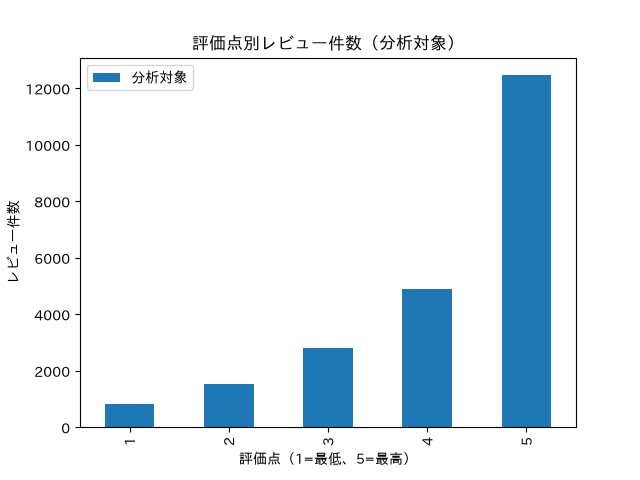

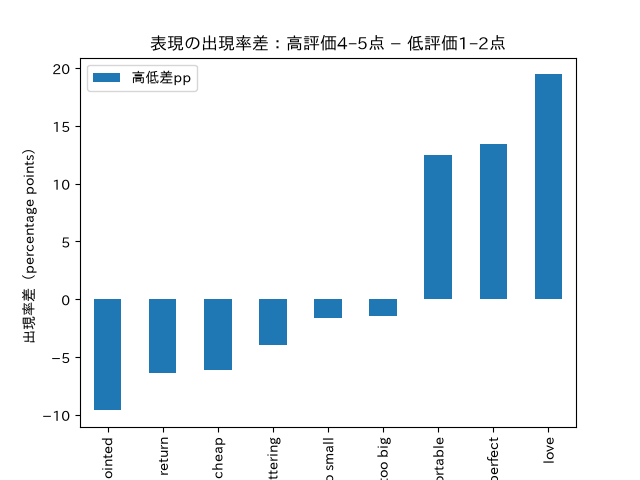

In [6]:
# 図表（MIMEと監査メタデータを保存）
from IPython.display import display
lifecycle.mark_execution_start(RUN_ID)
try:
    chart_counts = counts.reset_index()[['Rating','分析対象']].rename(columns={'Rating':'評価点'})
    delta_chart = term_table.loc[term_table['表現'].isin(anchors), ['表現','高低差pp']].sort_values('高低差pp')
    chart_specs = [
        (chart_counts, 'bar', '評価点', '分析対象', '評価点別レビュー件数（分析対象）', '評価点（1=最低、5=最高）', 'レビュー件数'),
        (delta_chart, 'bar', '表現', '高低差pp', '表現の出現率差：高評価4–5点 − 低評価1–2点', '本文中の表現', '出現率差（percentage points）')
    ]
    for frame, kind, x, y, title, xlabel, ylabel in chart_specs:
        png = visualization.render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
        output = visualization.build_image_output(png)
        display(output.data, metadata=output.metadata, raw=True)
        print('図監査metadata:', output.metadata)
finally:
    lifecycle.mark_execution_end(RUN_ID)


loveは高評価群で多いが、低評価群にも現れる。 高評価4–5点−低評価1–2点の出現率差は 19.447906999462706 percentage points。これは本文あり・言語proxy対象の記述的関連であり、単語から個々の感情を断定しない。

```evidence
{"execution_count":5,"cited_value":"19.447906999462706","claim_type":"associational"}
```


disappointedは低評価群で多い。 高評価4–5点−低評価1–2点の出現率差は -9.624920627167487 percentage points。これは本文あり・言語proxy対象の記述的関連であり、単語から個々の感情を断定しない。

```evidence
{"execution_count":5,"cited_value":"-9.624920627167487","claim_type":"associational"}
```


## 反復依頼履歴
### 反復1：前処理と比較群の感度
**追加依頼原文**
> 言語proxyが英語の短文も除外していることと重複定義の不確実性が気になります。言語proxyの有無、重複除去の有無、最低本文長、4–5点対1–2点と5点対1–2点の比較を変えて、主要表現の出現率差と向きがどの程度変わるか調べ、安定性を報告してください。

**選定理由**：品質確認でproxy未通過の117件に英語短文があり、前提A2・A3が未検証。初回の高低群比は約7.35倍であり、比較群の定義も結論を変えうる。結果・証拠は直後の実行セル。残る限界は商品・本文長の構成差と文脈解釈。

In [7]:
# 反復1：16仕様×主要6表現（予算は表現ごと16、途中切捨てなし）
lifecycle.mark_execution_start(RUN_ID)
try:
    sensitivity_rows = []
    def specification_delta(term, language_filter, deduplicate, min_words, high_cut):
        subset = body.loc[body['language_proxy']] if language_filter else body
        if deduplicate:
            subset = subset.drop_duplicates(['Clothing ID','Rating','normalized'])
        lengths = subset['normalized'].str.findall(r'\b[a-z]+\b').str.len()
        subset = subset.loc[lengths.ge(min_words)]
        prepared = tokenize_text(subset['normalized'])
        hit = prepared.str.contains(r'\b' + re.escape(term) + r'\b', regex=True)
        lo, hi = subset['Rating'].le(2), subset['Rating'].ge(high_cut)
        delta = float(100*(hit[hi].mean()-hit[lo].mean()))
        sensitivity_rows.append({'表現':term,'language_filter':language_filter,'deduplicate':deduplicate,'min_words':min_words,'high_cut':high_cut,'低n':int(lo.sum()),'高n':int(hi.sum()),'delta_pp':delta})
        return delta
    plan = sensitivity.SensitivityPlan(parameter_grid={'language_filter':[True,False], 'deduplicate':[True,False], 'min_words':[0,20], 'high_cut':[4,5]}, max_runs=16)
    sensitivity_reports = {}
    for term in ['love','perfect','comfortable','disappointed','cheap','not flattering']:
        report = sensitivity.run_sensitivity(plan, lambda term=term, **kwargs: specification_delta(term, **kwargs), stability_tolerance=.2)
        sensitivity_reports[term] = report
        print('感度結果:', term, 'stable=', report.stable, 'max_relative_deviation=', report.max_relative_deviation, 'baseline_pp=', report.baseline_value)
    sensitivity_df = pd.DataFrame(sensitivity_rows)
    sensitivity_summary = sensitivity_df.groupby('表現')['delta_pp'].agg(['min','max'])
    sensitivity_summary['符号一致'] = sensitivity_summary['min']*sensitivity_summary['max']>0
    print('範囲:', sensitivity_summary.to_string())
    print('全仕様数:', len(sensitivity_df), '全仕様の詳細はsensitivity_specifications.csvに保存')
    print('perfectの最大変動仕様:', sensitivity_df.loc[sensitivity_df['表現'].eq('perfect')].nlargest(1,'delta_pp').to_string(index=False))
    print('反復1結果：主要6表現は仕様別の符号を確認。stableは相対偏差20%閾値で判定し、符号一致とは別概念。')
    print('EVIDENCE_LOVE_SENS_MIN=' + str(float(sensitivity_summary.loc['love','min'])))
finally:
    lifecycle.mark_execution_end(RUN_ID)

{'EVIDENCE_LOVE_SENS_MIN':float(sensitivity_summary.loc['love','min']), 'perfect_max_relative_deviation':sensitivity_reports['perfect'].max_relative_deviation}


感度結果: love stable= True max_relative_deviation= 0.1918716069900092 baseline_pp= 19.447906999462706
感度結果: perfect stable= False max_relative_deviation= 0.2557770949422077 baseline_pp= 13.402383627216336
感度結果: comfortable stable= True max_relative_deviation= 0.1152325034720732 baseline_pp= 12.433839691300738
感度結果: disappointed stable= True max_relative_deviation= 0.04812316316499891 baseline_pp= -9.624920627167487
感度結果: cheap stable= True max_relative_deviation= 0.03902282085692289 baseline_pp= -6.1470473306305875
感度結果: not flattering stable= True max_relative_deviation= 0.08177659227833715 baseline_pp= -3.954867386313681
範囲:                       min        max  符号一致
表現                                        
cheap           -6.386922  -6.121698  True
comfortable     12.174632  13.866622  True
disappointed   -10.088102  -9.620490  True
love            19.044375  23.179408  True
not flattering  -4.278283  -3.938575  True
perfect         13.359786  16.830406  True
全仕様数: 96 全仕様の詳細はsensitiv

{'EVIDENCE_LOVE_SENS_MIN': 19.044374688846773,
 'perfect_max_relative_deviation': 0.2557770949422077}

### 反復1の結果
主要6表現の高低差は16仕様で符号一致。loveは19.04～23.18pp、disappointedは−10.09～−9.62pp。相対偏差20%基準ではperfectだけstable=False（25.58%）：高評価を5点だけにすると差が増すため、効果量を一つの普遍的な値として扱わない。同じ4–5点群に固定した前処理変更ではloveは19.04～19.46pp。

証拠：直前の感度セルの全96仕様集計と保存CSV、`sensitivity_summary` と `sensitivity_reports`。言語proxyや重複定義だけでは主要表現の方向は変わらなかったが、商品構成差は未解決。

```evidence
{"execution_count":7,"cited_value":"19.044374688846773","claim_type":"associational"}
```


### 反復2：商品・部門・本文長を考慮
**追加依頼原文**
> 主要表現の関連の向きは安定していますが、商品や部門の違い、本文長の違いで見かけの差が出ている可能性を確認してください。同じ商品に低評価と高評価がある場合の商品内比較、部門と本文長をそろえた比較、商品単位のブートストラップ区間を示し、適用対象と残る不確実性を明記してください。

**選定理由**：初回の5点レビューは他の評価より短く、商品や部門は無調整。前処理感度ではこれを解決できない。結果・証拠は直後のセル。残る限界は投稿者依存性と母集団への外挿。

In [8]:
# 反復2：共通支持での標準化・同一商品比較・商品クラスタ再標本化
lifecycle.mark_execution_start(RUN_ID)
try:
    selected_terms = ['love','perfect','comfortable','disappointed','cheap','not flattering']
    extreme = analyzed.loc[analyzed['Rating'].le(2) | analyzed['Rating'].ge(4)].copy()
    extreme['high'] = extreme['Rating'].ge(4)
    extreme['length_bin'] = pd.cut(extreme['word_count'], bins=[-1,20,50,80,np.inf], labels=['0–20','21–50','51–80','81+'])
    extreme['stratum'] = extreme['Department Name'].fillna('不明').astype(str) + ' / ' + extreme['length_bin'].astype(str)
    adjusted_rows = []
    rng = np.random.default_rng(45)
    item_ids = np.sort(extreme['Clothing ID'].unique())
    boot_indices = rng.integers(0, len(item_ids), size=(500,len(item_ids)))
    print('商品クラスタ数:', len(item_ids), 'bootstrap回数:500 seed:45')
    for term in selected_terms:
        hit = tokenize_text(extreme['normalized']).str.contains(r'\b' + re.escape(term) + r'\b')
        tmp = extreme.assign(hit=hit.astype(int))
        raw_delta = 100*(tmp.loc[tmp.high,'hit'].mean()-tmp.loc[~tmp.high,'hit'].mean())
        strata = tmp.groupby(['stratum','high'])['hit'].agg(['sum','size']).unstack('high')
        common = strata.loc[(strata[('size',False)]>=20) & (strata[('size',True)]>=20)]
        if common.empty:
            raise RuntimeError('標準化の共通支持がない')
        w = common[('size',False)]+common[('size',True)]
        strata_delta = 100*((common[('sum',True)]/common[('size',True)]-common[('sum',False)]/common[('size',False)])*w).sum()/w.sum()
        grouped = tmp.groupby(['Clothing ID','high'])['hit'].agg(['sum','size']).unstack('high').reindex(item_ids).fillna(0)
        paired = grouped.loc[(grouped[('size',False)]>=2) & (grouped[('size',True)]>=2)]
        paired_delta = 100*(paired[('sum',True)]/paired[('size',True)]-paired[('sum',False)]/paired[('size',False)]).mean()
        lo_hit = grouped[('sum',False)].to_numpy()[boot_indices].sum(axis=1)
        hi_hit = grouped[('sum',True)].to_numpy()[boot_indices].sum(axis=1)
        lo_n = grouped[('size',False)].to_numpy()[boot_indices].sum(axis=1)
        hi_n = grouped[('size',True)].to_numpy()[boot_indices].sum(axis=1)
        if (lo_n==0).any() or (hi_n==0).any():
            raise RuntimeError('bootstrapに評価群が空の標本あり')
        boot_delta = 100*(hi_hit/hi_n-lo_hit/lo_n)
        ci_low, ci_high = np.quantile(boot_delta,[.025,.975])
        adjusted_rows.append({'表現':term,'未調整pp':raw_delta,'部門×長さ標準化pp':float(strata_delta),'同一商品等重みpp':float(paired_delta),'商品bootstrap下限pp':float(ci_low),'商品bootstrap上限pp':float(ci_high),'共通層数':len(common),'共通層行数':int(w.sum()),'比較商品数':len(paired),'比較商品内行数':int(paired['size'].to_numpy().sum())})
    adjusted_df = pd.DataFrame(adjusted_rows)
    print('調整結果:', adjusted_df.to_string(index=False))
    print('同一商品比較は低群2件以上・高群2件以上の商品のみ。商品等重みであり全投稿者平均とは対象が異なる。')
    print('区間は固定した語に対する記述的クラスタbootstrap。探索後選定・多重比較・投稿者クラスタを補正しておらず確認的検定ではない。')
    print('EVIDENCE_ADJUSTED_LOVE=' + str(float(adjusted_df.loc[adjusted_df['表現'].eq('love'),'部門×長さ標準化pp'].iloc[0])))
finally:
    lifecycle.mark_execution_end(RUN_ID)
adjusted_df.round(6).to_dict(orient='records')


商品クラスタ数: 1098 bootstrap回数:500 seed:45
調整結果:             表現     未調整pp  部門×長さ標準化pp  同一商品等重みpp  商品bootstrap下限pp  商品bootstrap上限pp  共通層数  共通層行数  比較商品数  比較商品内行数
          love 19.447907   19.899901  22.911347        17.653434        21.352607    17  19115    195    16949
       perfect 13.402384   13.539380  12.627272        12.156781        14.642787    17  19115    195    16949
   comfortable 12.433840   12.129286  12.186594        11.263994        13.660629    17  19115    195    16949
  disappointed -9.624921   -9.510902 -10.212577       -11.004518        -8.330415    17  19115    195    16949
         cheap -6.147047   -6.175149  -6.713088        -7.203789        -5.215819    17  19115    195    16949
not flattering -3.954867   -3.905247  -3.296911        -4.772274        -3.296160    17  19115    195    16949
同一商品比較は低群2件以上・高群2件以上の商品のみ。商品等重みであり全投稿者平均とは対象が異なる。
区間は固定した語に対する記述的クラスタbootstrap。探索後選定・多重比較・投稿者クラスタを補正しておらず確認的検定ではない。
EVIDENCE_ADJUSTED_LOVE=19.899900646230243


[{'表現': 'love',
  '未調整pp': 19.447907,
  '部門×長さ標準化pp': 19.899901,
  '同一商品等重みpp': 22.911347,
  '商品bootstrap下限pp': 17.653434,
  '商品bootstrap上限pp': 21.352607,
  '共通層数': 17,
  '共通層行数': 19115,
  '比較商品数': 195,
  '比較商品内行数': 16949},
 {'表現': 'perfect',
  '未調整pp': 13.402384,
  '部門×長さ標準化pp': 13.53938,
  '同一商品等重みpp': 12.627272,
  '商品bootstrap下限pp': 12.156781,
  '商品bootstrap上限pp': 14.642787,
  '共通層数': 17,
  '共通層行数': 19115,
  '比較商品数': 195,
  '比較商品内行数': 16949},
 {'表現': 'comfortable',
  '未調整pp': 12.43384,
  '部門×長さ標準化pp': 12.129286,
  '同一商品等重みpp': 12.186594,
  '商品bootstrap下限pp': 11.263994,
  '商品bootstrap上限pp': 13.660629,
  '共通層数': 17,
  '共通層行数': 19115,
  '比較商品数': 195,
  '比較商品内行数': 16949},
 {'表現': 'disappointed',
  '未調整pp': -9.624921,
  '部門×長さ標準化pp': -9.510902,
  '同一商品等重みpp': -10.212577,
  '商品bootstrap下限pp': -11.004518,
  '商品bootstrap上限pp': -8.330415,
  '共通層数': 17,
  '共通層行数': 19115,
  '比較商品数': 195,
  '比較商品内行数': 16949},
 {'表現': 'cheap',
  '未調整pp': -6.147047,
  '部門×長さ標準化pp': -6.175149,
  '同一商品等重みpp': -6.71

### 反復2の結果
部門×本文長の共通17層、19,115レビューを標準化しても主要6表現の方向は維持。loveは未調整19.45pp、標準化19.90pp、同一商品等重み22.91pp。低・高群各2件以上の195商品、16,949レビューに対象を制限した同一商品比較でも符号は維持。1,098商品を500回再標本化したloveの記述的95%区間は17.65～21.35pp、disappointedは−11.00～−8.33pp。

証拠：直前の`adjusted_df`。これらは違う対象・重みの推定量であり一つの因果効果ではない。探索後選定・未知の投稿者依存・投稿者選択は未解決。文脈を失う語単位分析が次の重要な課題。

```evidence
{"execution_count":8,"cited_value":"19.899901","claim_type":"associational"}
```


### 反復3：肯定語と否定・期待・逆接の文脈
**追加依頼原文**
> 低評価にもloveが多く現れるので、単語だけで感情を決められない理由を確認してください。wanted to love、loveとbutの共存、not disappointedなどの限定的な表現パターンと評価点の関係を集計し、皮肉の検出とは区別して、単語頻度分析から言えることと言えないことを示してください。

**選定理由**：商品・長さ調整後も関連は維持したが、低群の17.2%にloveがあり、語からレビュー感情を直接判定する解釈は危険。結果・証拠は直後のセル。残る限界は構文全体・皮肉・複数対象・投稿者意図。

In [9]:
# 反復3：文脈パターン（自動感情/皮肉判定ではない）
lifecycle.mark_execution_start(RUN_ID)
try:
    prepared = tokenize_text(analyzed['normalized'])
    patterns = {
        'love（単語）': r'\blove\b',
        'wanted to love': r'\bwanted to love\b',
        'love と but が本文内に共存': r'(?s)(?=.*\blove\b)(?=.*\bbut\b)',
        'disappointed（単語）': r'\bdisappointed\b',
        'not/never + 0–2語 + disappointed': r'\b(?:not|never)\s+(?:[a-z]+\s+){0,2}disappointed\b',
        'not flattering': r'\bnot flattering\b',
        'too big': r'\btoo big\b',
        'too small': r'\btoo small\b'
    }
    context_rows = []
    context_hits = {}
    for name, pattern in patterns.items():
        hit = prepared.str.contains(pattern, regex=True)
        context_hits[name] = hit
        for rating in range(1,6):
            mask = analyzed['Rating'].eq(rating)
            context_rows.append({'表現':name, '評価点':rating, '件数':int(hit[mask].sum()), '群内n':int(mask.sum()), '出現率':float(hit[mask].mean())})
    context_df = pd.DataFrame(context_rows)
    print('文脈パターン件数:', context_df.pivot(index='表現',columns='評価点',values='件数').to_string())
    print('文脈パターン出現率:', context_df.pivot(index='表現',columns='評価点',values='出現率').to_string())
    low_love = analyzed['Rating'].le(2) & context_hits['love（単語）']
    low_love_n = int(low_love.sum())
    low_love_but_n = int((low_love & context_hits['love と but が本文内に共存']).sum())
    low_love_wanted_n = int((low_love & context_hits['wanted to love']).sum())
    print('低群love件数:', low_love_n, 'うちbut共存:', low_love_but_n, 'うちwanted to love:', low_love_wanted_n)
    print('短い期待文脈例:', analyzed.loc[low_love & context_hits['wanted to love'],'normalized'].head(4).str[:95].tolist())
    print('not/never disappointed件数:', int(context_hits['not/never + 0–2語 + disappointed'].sum()))
    print('意味的異常との区別：評価と推奨の非一致は両立し得る。本文語と点数の非一致も直ちに誤入力/皮肉ではない。')
    print('反復3結果：期待・逆接・否定の限定パターンを集計。皮肉ラベル/正解注釈がないので皮肉率・感情判定精度は推定しない。')
    print('EVIDENCE_LOW_LOVE_BUT=' + str(low_love_but_n))
finally:
    lifecycle.mark_execution_end(RUN_ID)
{'低群love':low_love_n,'低群love中but共存':low_love_but_n,'低群love中wanted to love':low_love_wanted_n}


文脈パターン件数: 評価点                                1    2    3     4     5
表現                                                        
disappointed（単語）                 101  149  161    74    94
love と but が本文内に共存                59  213  452   790  2330
love（単語）                          95  311  642  1328  5031
not flattering                    33   67  119    40     9
not/never + 0–2語 + disappointed    3    2    2    12    54
too big                           18   63  140   161   176
too small                         25   29   49    67    54
wanted to love                    22  101  149    37     9
文脈パターン出現率: 評価点                                     1         2         3         4         5
表現                                                                               
disappointed（単語）                 0.123623  0.096565  0.057255  0.015139  0.007543
love と but が本文内に共存               0.072215  0.138043  0.160740  0.161620  0.186968
love（単語）                         0.116279  0.201555  0.228307

{'低群love': 406, '低群love中but共存': 272, '低群love中wanted to love': 123}

### 反復3の結果と停止理由
低評価のlove 406件のうち272件でbutが共存し、123件にwanted to loveが現れる（両者は重なるので合計しない）。not/never＋最大2語＋disappointedは73件（最終統一tokenizer。初回の文字列照合では69件）で、そのうち66件が4–5点。肯定語は期待、否定語は否定の作用域に入り得る。本文内共存だけで逆接の対象や構文、皮肉を確定しない。

証拠：直前の文脈集計セル。初回tokenizerと文字列パターンで2語表現の件数に小差があったため、最終再実行では1文字の語も保持し、同じ文字列正規化を全分析に使用する。句読点を空白にするため文境界越しの連続語は残る限界。

**停止理由**：3回で前処理・商品/部門/長さ・否定/期待の主要未解決点を検証した。残る課題には皮肉の正解注釈、投稿者ID、未投稿者を含む母集団が必要で、手元データを追加加工しても識別できない。4回目は行わない。

```evidence
{"execution_count":9,"cited_value":"272","claim_type":"associational"}
```


## 結論と日本語での限界
高評価ではlove、perfect、comfortableなどの好意・満足・着心地に関する語が多く、低評価ではdisappointed、cheap、not flatteringなどの落胆・品質・見た目に関する表現が多い。サイズ表現too bigは3点で多く、すべての表現が単調に評価と対応するわけではない。高低群内の出現率比較を主指標とし、単純件数や全体正解率のように高評価多数派に支配される指標を避けた。

**言語・欠損・重複**：本文はラテン文字がほぼ全てで、英語機能語と短文例から主に英語と推定するが、全件の言語を認証したわけではない。本文欠損845件（約3.60%）は補完しない。5点の本文欠損率4.50%は1点2.49%より高く、欠損は評価から独立と仮定しない。タイトル欠損3,810件は本文分析の除外条件にしない。行番号除外の全属性一致は21件だが、多くは本文なしであり、本文分析では同一商品・評価・正規化本文の2件を除いた。短い同文だけで同一投稿者と断定せず、重複ありの感度も併記した。

**皮肉・文脈**：「素晴らしい、また壊れた」のような皮肉、期待していたが失望した文、否定の作用域、複数の商品側面は頻度だけでは判定できない。低評価と肯定語の同居を皮肉の証拠とはしない。感情分析モデルを追加しても正解注釈なしでは精度を検証できない。

**投稿者選択・外的妥当性**：レビューを書いた人だけのデータで、未投稿者・未購入者・投稿依頼や削除の過程は観測できない。非常に満足/不満な人の投稿選択、企業による公開選択、重複投稿・同じ人の別商品レビューが関係しうる。衣料品の匿名の単一ECデータに限定され、EC全体、日本語レビュー、購入者全体の満足度へは一般化できない。時期も不明で、商品クラスタ区間はこの選択バイアスを除去しない。表現が評価点を因果的に変えるとは言えない。

```evidence
{"execution_count":4,"cited_value":"845","claim_type":"descriptive"}
```


In [10]:
# 最終前提検査・派生表とmanifest保存
from dataclasses import replace
lifecycle.mark_execution_start(RUN_ID)
try:
    final_assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'question':'評価点と本文表現の関連','dataset':SLUG},
        assumptions=(
            analysis_assumptions.Assumption('A1','購入者母集団への外挿をしない', 'assumed', impact_if_false='非投稿者を含む母集団は観測できない'),
            analysis_assumptions.Assumption('A2','重複候補除去の有無で主要表現の方向を比較した', 'tested', impact_if_false='同文別人の可能性は残る', conclusion_critical=True),
            analysis_assumptions.Assumption('A3','英語proxy制限の有無で主要表現の方向を比較した', 'tested', impact_if_false='言語判定の正しさ自体は未検証', conclusion_critical=True),
            analysis_assumptions.Assumption('A4','本文あり投稿に分析対象を限定する', 'verified', impact_if_false='本文なし投稿の語は観測できない'),
            analysis_assumptions.Assumption('A5','商品・部門・本文長調整で主要語の方向を確認した', 'tested', impact_if_false='未観測交絡は残る', conclusion_critical=True),
            analysis_assumptions.Assumption('A6','語頻度を個別感情・皮肉率・因果効果とみなさない', 'verified')
        ), causal_scope='associational', sampling={'method':'全件から明示した品質基準で対象制限', 'n':len(analyzed), 'seed':45})
    final_findings = analysis_assumptions.check_manifest(final_assumptions)
    print('最終分析前提manifest:', json.dumps(asdict(final_assumptions), ensure_ascii=False))
    print('最終前提finding:', [asdict(f) for f in final_findings])
    tables = {'rating_counts':counts, 'expression_associations':term_table, 'rating_profiles':profile_df, 'sensitivity_specifications':sensitivity_df, 'adjusted_associations':adjusted_df, 'context_patterns':context_df}
    lifecycle.mark_write_start(RUN_ID)
    try:
        for name, table in tables.items():
            table.to_csv(Path(data_dir)/(name+'.csv'), index=name=='rating_counts')
        for name, payload in [('provenance',provenance),('data_definition_manifest',asdict(definition_manifest)),('analysis_assumptions_manifest',asdict(final_assumptions))]:
            (Path(data_dir)/(name+'.json')).write_text(json.dumps(payload,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
    finally:
        lifecycle.mark_write_end(RUN_ID)
    print('保存済み派生表:', list(tables))
    print('前提findingは0でも、言語の確定・投稿者選択・非観測交絡を解消したという意味ではない。')
finally:
    lifecycle.mark_execution_end(RUN_ID)
{'最終前提finding数':len(final_findings), '意味的異常数':len(semantic_anomalies), '分析対象数':len(analyzed)}


最終分析前提manifest: {"analysis_scope": {"question": "評価点と本文表現の関連", "dataset": "nicapotato/womens-ecommerce-clothing-reviews"}, "assumptions": [{"id": "A1", "statement": "購入者母集団への外挿をしない", "status": "assumed", "evidence_cell": null, "impact_if_false": "非投稿者を含む母集団は観測できない", "conclusion_critical": false}, {"id": "A2", "statement": "重複候補除去の有無で主要表現の方向を比較した", "status": "tested", "evidence_cell": null, "impact_if_false": "同文別人の可能性は残る", "conclusion_critical": true}, {"id": "A3", "statement": "英語proxy制限の有無で主要表現の方向を比較した", "status": "tested", "evidence_cell": null, "impact_if_false": "言語判定の正しさ自体は未検証", "conclusion_critical": true}, {"id": "A4", "statement": "本文あり投稿に分析対象を限定する", "status": "verified", "evidence_cell": null, "impact_if_false": "本文なし投稿の語は観測できない", "conclusion_critical": false}, {"id": "A5", "statement": "商品・部門・本文長調整で主要語の方向を確認した", "status": "tested", "evidence_cell": null, "impact_if_false": "未観測交絡は残る", "conclusion_critical": true}, {"id": "A6", "statement": "語頻度を個別感情・皮肉率・因果効果とみなさない", "status"

{'最終前提finding数': 0, '意味的異常数': 0, '分析対象数': 22522}

## 適用できない機能と理由
独立した参照データは提供されず、同一CSVの再取得は独立検証ではないため、`data_quality.validate_anomalies` と `dataset_validation.compare_datasets` は未適用。自然言語の異常を数値z-scoreで判定せず、範囲・カテゴリ・欠損・一意性の意味的検査を実施。予測モデルの学習、因果推論、皮肉分類精度は目的/識別条件/正解注釈を満たさず未適用。`langdetect`/`langid` は環境にないため、追加インストールせず言語proxyと実例・感度で限界を明記。`stats_analysis.correlation` は順序評価と多数の二値語の単一相関に要約すると文脈と群差が失われるため未使用。

`mcp_gateway.run_and_record` はNotebook内に追加のMCPクライアントを作って再帰実行せず未使用。コードの実行・保存は設定済みDatalayer Jupyter MCPの`execute_cell`、Notebookへの追加/更新は`project_manager.enqueue_write`を使った。外部スクリプト・端末・subprocess・作業エージェントは未使用。

## 使用したJupytermindモジュール
直接import・呼出しだけを以下に列挙する。間接利用は含めない。

|モジュール（`ai_data_scientist.`配下）|直接呼んだ関数・クラス|目的|
|---|---|---|
|project_manager|resolve_project, ensure_notebook, ensure_data_dir, enqueue_write|保存先固定、Notebook/データ領域と直列書込み|
|language_router|detect_language|日本語出力の選択|
|lifecycle|register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status|実行・書込み・終端状態の記録|
|ingestion|SourceSpec, ingest|取得済みCSVを上限付きで読込み|
|cleaning|clean_dataset|全行重複除去impact確認。指定キーの除去はpandasで回避|
|eda|explore|型・欠損・要約の探索|
|data_definition|FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields|変数定義・出所・未知/推定の可視化|
|analysis_assumptions|Assumption, AnalysisAssumptionManifest, check_manifest|非因果の分析前提とfinding|
|data_quality|detect_anomalies|点数範囲・カテゴリ・年齢・件数・一意性の意味検査|
|sensitivity|SensitivityPlan, run_sensitivity|16仕様/表現の安定性確認|
|visualization|render_chart, build_image_output|日本語図表と監査情報付き画像MIME|
|insight_engine|extract_cited_value, record_insight|実出力からの引用と根拠付きinsight|
|notebook_audit|audit_notebook(visual_audit=True)|全コード・証拠・画像の最終監査|

`data_definition.DataDefinitionManifest` はbuild_manifestの返り値のメソッドとして直接呼んだ。外部ライブラリpandas、NumPy、scikit-learn、nbformat、Kaggle SDK、IPythonはJupytermindモジュールではない。

## Jupytermind改善候補
### 候補1：stream出力の根拠照合（要調査）
**分類**：insight_engineの出力形式対応不足/不具合疑い。

**再現条件**：主分析セルの実行済みstream出力に`EVIDENCE_LOVE_DELTA_PP=19.447906999462706`があり、保存Notebookから同じ値とexecution_count=19を抽出し、`record_insight`を呼ぶ。

**期待する挙動**：実際に保存された実行済みセルのstream中の引用値を根拠として受け入れる、または非対応の出力型を明示する。

**実際の挙動**：`EvidenceMissingError`「根拠となる実行済みセル(execution_count=19)が見つからない」。同じ値をセル末尾式のexecute_result（text/plain）にも出力して再実行すると記録に成功した。値・Notebookのパスは同じ。例外は握りつぶさず記録を中止し、出力型を変えて再試行。

**影響**：print中心の分析から根拠付きinsightを作れない可能性。

**回避策**：証拠値を実際のセル末尾式のexecute_resultにも出力し、そこから正確に抽出する。データや出力を捏造しない。

**関係セルとログ**：本Notebookの主分析セル（# 評価点と表現の関連）、insight Markdown、`benchmark/v020-exp-45-bootstrap.ipynb`のセル7の初回エラー（execution_count=22）と再試行成功（25）、セル8の回避策（23）。同セルの再実行で初回エラー出力は更新されたため、この節に例外型・メッセージ・前後条件を保存。

**切り分け**：Kaggle取得は別に成功済み。Copilot CLI/MCPはstreamをNotebookに保存しており、同じファイルをnbformatで読んで引用値を抽出できた。execute_result追加のみで改善するためJupytermind側の照合対象が疑われるが、内部の原因は未確定。ベンチマークランナーは起動していない。

### Jupytermind以外の問題
Kaggle SDKのdataset_view不存在とZIP名URLエンコードは取得コード/API互換性問題で解決済み。初期のNotebook親ディレクトリ未作成とbootstrapの相対root二重化はクライアント初期化上の問題で、絶対rootを明示して解決。register_run引数不足は呼出し側の誤り。filesystem MCPはこのリポジトリを許可ディレクトリに含まずソース読込み不可だったが、データ分析には不要で、Notebook内の公開APIシグネチャ確認を使った。これらをJupytermind不具合とは数えない。

### 候補2：指定列による重複除去の未対応/引数無視疑い
**分類**：cleaning.clean_datasetの機能不足または引数の適用範囲が不明確。

**再現条件**：本文ありのbase 22,524行へ`clean_dataset(base, operation="drop_duplicates", columns=["Clothing ID","Rating","normalized"])`を呼ぶ。同キーの重複候補は2件あり、出力行番号はユニーク。

**期待する挙動**：columnsが重複キーを意味するなら22,522行になる。対応しないなら明示的に拒否するか、columnsはdrop_duplicatesに無効と説明する。

**実際の挙動**：rows_before=22524, rows_after=22524, rows_removed=0、columns_affectedは全列、返り値に同キーの重複2件が残る。

**影響**：指定キーで除去できたと誤解してレビューを重複計数し得る。今回のlove差は19.447907ppから19.458844ppへ変わる小差だったが、利用者が気付かないと分析前提を満たせない。

**回避策**：pandasの`base.drop_duplicates(subset=dup_subset)`を明示し、残存重複ゼロをassert。最終分析は22,522行。JupytermindへのAPI変更はこの分析では行わない。

**関係セル・ログ**：本Notebookの品質確認セルにcleaning impact、残存キー重複、pandas回避後impactを保存。最初の全再実行時のkernel確認出力はrows_removed=0/残存2、bootstrapの修正セルに経緯を保存。

**切り分け**：CSVのSHA-256は再取得でも一致し、Kaggle/MCP/ベンチマークランナーで行数が変わったわけではない。同じDataFrameのpandas操作では指定キー2件が除去される。columnsの公開シグネチャだけでは意図を確定できないため、バグ断定ではなく機能/仕様明確化の候補とする。

### 候補3：実行中Notebook書込みとMCP出力保存の統合ガイド
**分類**：JupytermindとJupyter MCPの統合上の機能/ガイド不足疑い（内部原因未確定）。

**再現条件**：主Notebook最終セルの実行中に同じファイルへenqueue_writeで根拠Markdownを更新する。

**期待する挙動**：実行中セルのexecution_count・出力が保持される、または同時書込みの制限を明示し安全な後処理を案内する。

**実際の挙動**：kernelではaudit_reportが生成されrun state=completed、active/pending=0だが、execute_cellの応答は出力なし、ディスクの最終セルはexecution_count=None/outputs=[]。根拠更新は保存された。

**影響**：監査の末尾除外だけでOKとすると、最終監査・状態ログがNotebookに残らない。

**回避策**：根拠countを照合し更新不要なら自己再書込みをしない。更新が必要だった場合は監査セルを再実行し、完了後に全コード数と実行済み数の一致まで確認する。

**関係セル・ログ**：主Notebook最終セルとこの節。失われた実行後のread-only確認はcode_cell_count=11/executed=10、最終セルNone/0 outputs、state=completed。

**切り分け**：Kaggleと分析は成功し、benchmark runnerは未使用。MCPが独自のNotebookオブジェクトを持つ問題の可能性もあり、Jupytermind単体の保存バグとは断定しない。CLI/SDK固有の問題として分類せず、共有Notebookを扱う統合ガイドの改善候補として記録する。

## 上からの全再実行・最終監査
初回分析と3反復を読み直した後、kernelを再起動し、全コードセルを上から順にJupyter MCPで再実行する。最終セルは現実の出力を再抽出して根拠manifestのexecution_countを更新し、`notebook_audit.audit_notebook(..., visual_audit=True)`で検査する。図表はタイトル・軸・日本語字形・描画密度のメタデータ監査に加え、初回出力画像で棒とラベルの可読性を目視確認した。監査不合格時はcompletedとせずfailedにする。

自己Notebookへのenqueue_writeを実行中に行うとMCPの出力保存と競合する可能性があったため、根拠の更新済みcountを確認して不要な再書込みを避ける。必要な場合は更新後に監査セルをもう一度実行し、最終セル自体を含む全コードの永続出力を確認する。

In [16]:
# 最終：実出力の再照合、visual_audit=True、ライフサイクル終端
lifecycle.mark_execution_start(RUN_ID)
try:
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検知')
    def refresh_evidence(nb):
        cells_by_id = {c.id:c for c in nb.cells}
        for cell in nb.cells:
            source_id = cell.metadata.get('evidence_source_cell_id')
            if not source_id:
                continue
            ref = cells_by_id[source_id]
            if ref.execution_count is None or any(o.output_type=='error' for o in ref.outputs):
                raise RuntimeError('未実行/エラーの根拠セル')
            output_text = '\n'.join(o.get('text','') + o.get('data',{}).get('text/plain','') for o in ref.outputs)
            cited = insight_engine.extract_cited_value({'output':output_text}, cell.metadata['evidence_pattern'])
            manifest = {'execution_count':ref.execution_count,'cited_value':cited,'claim_type':'associational' if cell.source.startswith(('love','disappointed','### 反復')) else 'descriptive'}
            cell.source = re.sub(r'\n*```evidence\n.*?\n```\n*', '', cell.source, flags=re.S).rstrip() + '\n\n```evidence\n' + json.dumps(manifest,ensure_ascii=False,separators=(',',':')) + '\n```\n'
        nb.metadata['retrieval_provenance'] = provenance
        nb.metadata['reexecution_policy'] = 'kernel restart followed by every code cell in top-to-bottom order via Jupyter MCP'
        nb.metadata['final_data_definition_manifest'] = asdict(definition_manifest)
        nb.metadata['final_analysis_assumptions_manifest'] = asdict(final_assumptions)
    saved_nb = nbformat.read(handle.notebook_path, as_version=4)
    saved_by_id = {c.id:c for c in saved_nb.cells}
    needs_refresh = any(json.loads(re.search(r'```evidence\n(.*?)\n```', c.source, flags=re.S).group(1))['execution_count'] != saved_by_id[c.metadata['evidence_source_cell_id']].execution_count for c in saved_nb.cells if c.metadata.get('evidence_source_cell_id'))
    if needs_refresh:
        lifecycle.mark_write_start(RUN_ID)
        try:
            pm.enqueue_write(handle, refresh_evidence)
        finally:
            lifecycle.mark_write_end(RUN_ID)
    else:
        print('根拠manifest: 最新execution_countと照合済み、再書込み不要')
    audit_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    print('notebook_audit:', json.dumps(asdict(audit_report),ensure_ascii=False,default=str,indent=2))
    print('audit.ok:', audit_report.ok)
finally:
    lifecycle.mark_execution_end(RUN_ID)
if audit_report.ok and not final_findings and provenance['status']=='success':
    lifecycle.mark_completed(RUN_ID)
else:
    lifecycle.mark_failed(RUN_ID)
print('最終lifecycle:', json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False,default=str,indent=2))
if not audit_report.ok:
    raise RuntimeError('Notebook監査不合格。findingの修復が必要')
{'audit_ok':audit_report.ok,'visual_audit':True,'lifecycle':lifecycle.get_run_status(RUN_ID).state,'run_id':RUN_ID}


根拠manifest: 最新execution_countと照合済み、再書込み不要
notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-45-product-reviews/notebooks/kaggle-v020-kaggle-exp-45-product-reviews.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 11,
  "executed_code_cell_count": 11,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    10
  ],
  "insight_cell_count": 2,
  "findings": [],
  "visual_findings": []
}
audit.ok: True
最終lifecycle: {
  "run_id": "v020-exp-45",
  "state": "completed",
  "active_cell_executions": 0,
  "pending_notebook_writes": 0,
  "locks_held": 0,
  "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-45-product-reviews/notebooks/kaggle-v020-kaggle-exp-45-product-reviews.ipynb",
  "reason": null
}


{'audit_ok': True,
 'visual_audit': True,
 'lifecycle': 'completed',
 'run_id': 'v020-exp-45'}